# Milestone 1: Fisher Analysis of the EIGSEP Rotation Grid

Characterize the information content and systematic floor of the rotation grid **before any inference**.

## Background

The EIGSEP antenna measures the beam-weighted sky brightness temperature. In the spherical harmonic domain, the measurement at mechanical rotation $R_i$ and local sidereal time $t_j$ is (memo Eq. 4):

$$T_\text{ant}(R_i, t_j) = \sum_{\ell,m,m'} b_{\ell m'}\, D^\ell_{mm'}(R_i)\, a_{\ell m} + T_\text{gnd} \sum_{\ell m} b_{\ell m}\, H_{\ell m}(R_i) + n$$

This equation is **bilinear** in the beam $b_{\ell m}$ and sky $a_{\ell m}$ — a single Wiener filter cannot solve it. The memo proves an **identifiability theorem**: under six conditions (SO(3) coverage, known $T_\text{gnd}$, known horizon, full-rank $C$-matrix, non-degenerate signals, and sky asymmetry), the beam and sky are uniquely recoverable via a constructive three-step estimator: Wigner projection $\to$ rank-1 SVD $\to$ ground-term linear system.

Before implementing that estimator, we must characterize the **systematic floor** set by three error terms that appear whenever the Wigner projection is applied to finite, discrete data:

1. **(i) Cross-$\ell$ leakage** — deterministic bias from the finite mechanical rotation grid not perfectly sampling SO(3). Quantified by the **coverage kernel** $K^{\ell_0,\ell}$, which equals $\delta_{\ell_0,\ell} I$ under Haar measure.
2. **(ii) LST sampling error** — deterministic bias from discrete sidereal time sampling. For $N_t$ uniformly spaced LST samples, modes with $|m| < N_t/2$ are recovered to machine precision; higher modes alias.
3. **(iii) Noise** — random, zero mean, shrinks as $1/\sqrt{N_\text{obs}}$.

Errors (i) and (ii) are **known biases** computable from the rotation grid and LST schedule alone, before any data are taken. They set the systematic floor regardless of integration time, and directly inform which beam modes the Milestone 2 prior sweep should target.

Additionally, condition **C6 (sky asymmetry)** requires the sky to have nonzero $m' \neq 0$ power at each $\ell$ for the beam shape to be recoverable from the LST residual. The **sky asymmetry SNR** quantifies this per multipole.

Finally, the **Fisher information matrix** gives the joint Cramér–Rao bound on all beam and sky parameters, revealing the fundamental precision limit and identifying degenerate directions.

**Data:** EIGSEP bowtie beam (HFSS) + GSM16 sky at 100 MHz.

See `memo/sample631.tex` Sections 3–4 and `PROBLEM_STATEMENT.md` for the full mathematical derivation.

In [1]:
import jax

jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import s2fft
from croissant.rotations import rotmat_to_eulerZYZ
from pygdsm import GlobalSkyModel16

import eigsim
from eigsim.rotations import rotation_matrix_x, rotation_matrix_z
from rotis.fisher import (
    _rotmats_to_D,
    compute_fim,
    coverage_kernel,
    lst_sampling_error,
    plot_milestone1_summary,
    sky_asymmetry_snr,
)

%matplotlib inline

In [2]:
# --- Configuration ---

LMAX_WORK = 8  # working bandlimit (increase for finer analysis, slower FIM)
L_WORK = LMAX_WORK + 1

FREQ_MHZ = 100.0  # single frequency for this analysis

N_LST = 24  # hourly LST sampling over one sidereal day
LSTS_RAD = np.linspace(0, 2 * np.pi, N_LST, endpoint=False)

LAT_RAD = np.radians(39.2477)  # EIGSEP site latitude

# Radiometer noise: sigma = T_sys / sqrt(delta_f * delta_t)
# T_sys ~ 350 K, delta_f = 1 MHz, delta_t = 60 s => sigma ~ 0.045 K
NOISE_VAR = 0.045**2

# Number of rotations for FIM (subset of full grid for speed)
N_ROT_FIM = 100

print(f"Working lmax: {LMAX_WORK}")
print(f"Parameters per field: {L_WORK**2}")
print(f"Total parameters (beam + sky): {2 * L_WORK**2}")
print(f"LST samples: {N_LST}")
print(f"Noise std: {np.sqrt(NOISE_VAR):.4f} K")

Working lmax: 8
Parameters per field: 81
Total parameters (beam + sky): 162
LST samples: 24
Noise std: 0.0450 K


## Data Preparation

Load the EIGSEP beam and GSM16 sky, compute spherical harmonic coefficients, and
truncate to the working bandlimit.

### Coordinate systems

The forward model factorizes the total rotation as $R_\text{total} = R_z(\text{LST}) \cdot R_\text{fixed}$, where $R_\text{fixed}$ maps the antenna body frame to equatorial coordinates (excluding LST). For the LST part to be a pure $z$-rotation — giving the clean phase factor $e^{im t_j}$ — everything must be expressed in equatorial coordinates:

- **Beam** $b_{\ell m}$: in the antenna body frame (native from HFSS). The $D$-matrices handle the rotation from body to equatorial.
- **Sky** $a_{\ell m}$: must be in **equatorial** coordinates. GSM16 outputs galactic coordinates, so we apply the galactic-to-equatorial Wigner $D$-rotation.
- **$D$-matrices**: encode $R_\text{fixed} = R_x(\lambda - \pi/2) \cdot R_\text{mech}$, where $\lambda$ is the site latitude and $R_\text{mech} = R_x(\text{elev}) \cdot R_z(\text{az})$. The latitude rotation tilts the local zenith to the celestial pole. Since both are $x$-rotations, this simplifies to $R_\text{fixed} = R_x(\lambda - \pi/2 + \text{elev}) \cdot R_z(\text{az})$.

In [3]:
def truncate_alm(alm, L_from, L_to):
    """Extract low-l alm from a higher-bandlimit s2fft array."""
    out = np.zeros((L_to, 2 * L_to - 1), dtype=np.complex128)
    c_from, c_to = L_from - 1, L_to - 1
    for ell in range(L_to):
        out[ell, c_to - ell : c_to + ell + 1] = np.array(
            alm[ell, c_from - ell : c_from + ell + 1]
        )
    return jnp.array(out)

In [4]:
# Load EIGSEP beam and compute alm at one frequency
freqs_hz, beam_data, lmax_beam = eigsim.load_beam()
freqs_mhz = freqs_hz / 1e6
L_beam = lmax_beam + 1

freq_idx = int(np.argmin(np.abs(freqs_mhz - FREQ_MHZ)))
print(f"Beam frequency: {freqs_mhz[freq_idx]:.1f} MHz (index {freq_idx})")

beam_alm_full = eigsim.beam_to_alm(
    beam_data[freq_idx : freq_idx + 1], lmax_beam, "mwss"
)[0]
beam_alm = truncate_alm(beam_alm_full, L_beam, L_WORK)
print(f"Beam alm: {beam_alm_full.shape} -> {beam_alm.shape}")

# Power spectrum
Cl_beam = np.array(
    [float(jnp.sum(jnp.abs(beam_alm[ell]) ** 2)) for ell in range(L_WORK)]
)
print(f"Beam C_l: {['%.2e' % c for c in Cl_beam]}")

Beam frequency: 100.0 MHz (index 50)
Beam alm: (129, 257) -> (9, 17)
Beam C_l: ['1.22e+01', '1.05e-01', '2.23e+00', '4.25e-03', '3.76e-02', '2.92e-04', '2.31e-05', '6.17e-08', '1.45e-08']


In [5]:
# Generate sky from GSM16 and compute alm
gsm = GlobalSkyModel16(
    freq_unit="MHz", data_unit="TRJ", resolution="lo", include_cmb=True
)
sky_map = gsm.generate(FREQ_MHZ)
npix = sky_map.shape[0]
nside = int(np.sqrt(npix / 12))
print(f"GSM16 sky: {npix} pixels, nside={nside}, T range [{sky_map.min():.0f}, {sky_map.max():.0f}] K")

# SHT via s2fft (compute at moderate L, then truncate)
L_sky_sht = 2 * nside
sky_alm_gal = s2fft.forward(
    jnp.array(sky_map),
    L=L_sky_sht,
    sampling="healpix",
    nside=nside,
    method="jax",
    spin=0,
    reality=True,
)

# Rotate sky from galactic to equatorial (J2000) coordinates.
# The standard rotation matrix (IAU definition):
R_eq_to_gal = np.array([
    [-0.0548755604, +0.4941094279, -0.8676661490],
    [-0.8734370902, -0.4448296300, -0.1980763734],
    [-0.4838350155, +0.7469822445, +0.4559837762],
])
R_gal_to_eq = R_eq_to_gal.T
euler_gal_to_eq = rotmat_to_eulerZYZ(R_gal_to_eq)
print(f"Galactic-to-equatorial Euler angles (ZYZ): "
      f"({np.degrees(euler_gal_to_eq[0]):.2f}, "
      f"{np.degrees(euler_gal_to_eq[1]):.2f}, "
      f"{np.degrees(euler_gal_to_eq[2]):.2f}) deg")

dl_gal = s2fft.generate_rotate_dls(L_sky_sht, euler_gal_to_eq[1])
sky_alm_eq_full = s2fft.utils.rotation.rotate_flms(
    sky_alm_gal, L=L_sky_sht, rotation=euler_gal_to_eq, dl_array=dl_gal
)

sky_alm = truncate_alm(sky_alm_eq_full, L_sky_sht, L_WORK)
print(f"Sky alm: {sky_alm_eq_full.shape} -> {sky_alm.shape} (equatorial frame)")

Cl_sky = np.array(
    [float(jnp.sum(jnp.abs(sky_alm[ell]) ** 2)) for ell in range(L_WORK)]
)
print(f"Sky C_l: {['%.2e' % c for c in Cl_sky]}")

GSM16 sky: 49152 pixels, nside=64, T range [413, 9977] K
Galactic-to-equatorial Euler angles (ZYZ): (122.93, 62.87, -12.86) deg
Sky alm: (128, 255) -> (9, 17) (equatorial frame)
Sky C_l: ['1.54e+07', '1.99e+06', '2.43e+06', '5.77e+05', '1.16e+06', '4.15e+05', '6.43e+05', '2.98e+05', '3.84e+05']


In [6]:
# Build rotation grid from EIGSEP config
cfg = eigsim.load_config()
elev_vals = np.array(cfg["orientations"]["elevations"], dtype=float)
az_vals = np.array(cfg["orientations"]["azimuths"], dtype=float)

elev_grid, az_grid = np.meshgrid(elev_vals, az_vals, indexing="ij")
elev_flat = elev_grid.ravel()
az_flat = az_grid.ravel()
N_rot_total = len(elev_flat)

# Include the site latitude in the rotation matrices so the D-matrices
# encode R_fixed = Rx(lat - pi/2 + elev) @ Rz(az), which maps the antenna
# body frame to equatorial coordinates (excluding the LST z-rotation).
# This is needed for the phase factor exp(i*m*LST) to correctly represent
# Earth rotation as a pure z-rotation in equatorial coordinates.
colat_offset_deg = np.degrees(LAT_RAD) - 90.0  # lat - 90 deg
rotation_matrices_all = np.stack([
    rotation_matrix_x(np.radians(colat_offset_deg + e)) @ rotation_matrix_z(np.radians(a))
    for e, a in zip(elev_flat, az_flat)
])
print(f"Rotation grid: {len(elev_vals)} elev x {len(az_vals)} az = {N_rot_total} orientations")
print(f"Latitude offset: {colat_offset_deg:.2f} deg (body-to-equatorial)")

# Uniform Haar weights
weights = jnp.full(N_rot_total, 8 * np.pi**2 / N_rot_total)

Rotation grid: 36 elev x 36 az = 1296 orientations
Latitude offset: -50.75 deg (body-to-equatorial)


## Coverage Kernel — Error Term (i)

The coverage kernel $K^{\ell_0,\ell}$ measures how faithfully the finite rotation grid approximates the SO(3) Haar integral. Under Haar measure (memo Sec. 4.1):

$$K^{\ell_0,\ell}_{m_0 m'_0; m m'} = \frac{2\ell_0+1}{8\pi^2} \sum_i w_i\, \overline{D^{\ell_0}_{m_0 m'_0}(R_i)}\, D^\ell_{mm'}(R_i) = \delta_{\ell_0,\ell}\,\delta_{m_0,m}\,\delta_{m'_0,m'}$$

Deviations from this identity are the cross-$\ell$ leakage — a **known, deterministic bias** computable from the rotation matrices alone (no data needed). It biases the Wigner projection of Sub-step 1a of the theorem and propagates into the rank-1 SVD.

The EIGSEP site at latitude $\lambda \approx 39°$ gives $\cos\lambda \approx 0.77$, so Earth rotation sweeps a large, independent arc relative to the mechanical axes (tilt and turntable). Coverage is best at intermediate latitudes; at the equator or pole, only two independent axes remain (memo Table 1).

**Diagnostics:**
- Diagonal completeness: $K^{\ell,\ell}$ diagonal elements should be $\approx 1$.
- Off-diagonal leakage: $\sum_{\ell \neq \ell_0} \|K^{\ell_0,\ell}\|_F^2$ measures the total power leaking into each $\ell_0$ from other multipoles.

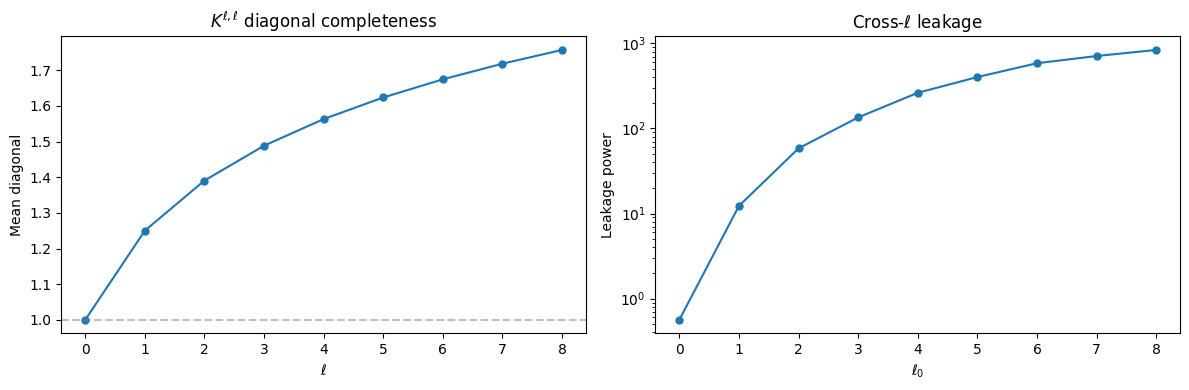

Diagonal completeness range: [1.0000, 1.7569]
Max off-diagonal leakage: 8.38e+02


In [7]:
diagonal, offdiag_power = coverage_kernel(rotation_matrices_all, weights, LMAX_WORK)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ell = np.arange(L_WORK)

# Diagonal completeness (should be ~1)
diag_mean = np.array(
    [
        float(jnp.mean(jnp.diag(diagonal[l])[L_WORK - 1 - l : L_WORK + l]))
        for l in range(L_WORK)
    ]
)
ax1.plot(ell, diag_mean, "o-", ms=5)
ax1.axhline(1.0, color="gray", ls="--", alpha=0.5)
ax1.set_xlabel(r"$\ell$")
ax1.set_ylabel("Mean diagonal")
ax1.set_title(r"$K^{\ell,\ell}$ diagonal completeness")

# Off-diagonal leakage power
ax2.semilogy(ell, np.maximum(np.array(offdiag_power), 1e-30), "o-", ms=5)
ax2.set_xlabel(r"$\ell_0$")
ax2.set_ylabel("Leakage power")
ax2.set_title(r"Cross-$\ell$ leakage")

fig.tight_layout()
plt.show()

print(f"Diagonal completeness range: [{diag_mean.min():.4f}, {diag_mean.max():.4f}]")
print(f"Max off-diagonal leakage: {float(jnp.max(offdiag_power)):.2e}")

## LST Sampling Error — Error Term (ii)

The constructive estimator isolates the sky term via the LST residual $\delta y(R_\text{mech}, t) = y - \bar{y}$, where the LST mean $\bar{y}$ removes the ground term (constant in LST). The continuous sidereal average projects out the $m'=0$ sky modes exactly. With discrete sampling, this introduces a quadrature error (memo Eq. in Sec. 3.2):

$$\psi(m) = \frac{1}{N_t} \sum_j e^{-imt_j} - \delta_{m,0}$$

For $N_t$ uniformly spaced LST samples, $|\psi(m)| < \epsilon_\text{mach}$ for $|m| < N_t/2$ (Nyquist limit). Above this, modes alias with $|\psi| = O(1)$.

Since LST rotation in equatorial coordinates is a pure $z$-rotation, $\eta[\ell, m, m'] = \delta_{m,m'} \cdot \psi(m)$ — the error is diagonal and identical for all $\ell$.

With $N_t = 24$ hourly samples, the Nyquist limit is $|m| < 12$, safely above our working $\ell_\text{max} = 8$.

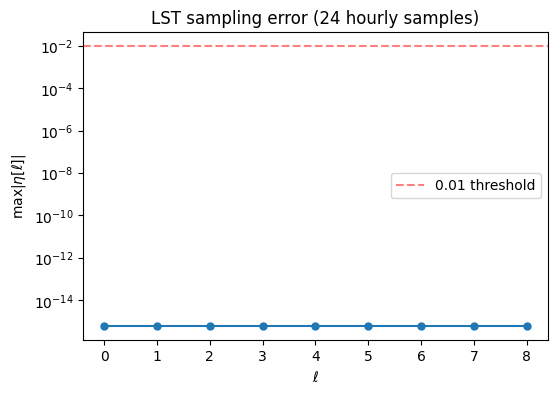

Nyquist limit: |m| < 12
Working lmax = 8 < Nyquist 12
Max |eta| at working lmax: 6.25e-16


In [8]:
eta = lst_sampling_error(LSTS_RAD, LAT_RAD, LMAX_WORK)

max_eta = np.array(
    [np.max(np.abs(np.array(eta[l]))) for l in range(L_WORK)]
)

fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(ell, np.maximum(max_eta, 1e-30), "o-", ms=5)
ax.axhline(0.01, color="r", ls="--", alpha=0.5, label="0.01 threshold")
ax.set_xlabel(r"$\ell$")
ax.set_ylabel(r"$\max|\eta[\ell]|$")
ax.set_title(f"LST sampling error ({N_LST} hourly samples)")
ax.legend()
plt.show()

print(f"Nyquist limit: |m| < {N_LST // 2}")
print(f"Working lmax = {LMAX_WORK} {'<' if LMAX_WORK < N_LST // 2 else '>='} Nyquist {N_LST // 2}")
print(f"Max |eta| at working lmax: {max_eta.max():.2e}")

## Sky Asymmetry SNR — Condition C6

The beam shape $\hat{\mathbf{b}}_\ell$ is estimated from the $m' \neq 0$ columns of $X_\ell = \mathbf{b}_\ell \mathbf{a}_\ell^T$ (Sub-step 1a of the theorem proof). This requires the sky to have nonzero $m' \neq 0$ power at each $\ell$ — **condition C6**. If the sky were perfectly axisymmetric at some $\ell$ (all power in $m'=0$), the $m' \neq 0$ block vanishes and the beam shape cannot be recovered from the LST residual at that $\ell$.

The quality of the beam shape estimate scales with the SNR of the $m' \neq 0$ sky modes (memo Sec. 4.6):

$$\text{SNR}_{\hat{b}_\ell} \sim \frac{\|\mathbf{b}_\ell\| \cdot \|[a_{\ell m'}]_{m'\neq 0}\|}{\sigma_\text{noise}}$$

This SNR degrades at high $\ell$ (faint small-scale sky modes) and at high frequency (faint sky overall). For the real diffuse radio sky, the Galactic plane provides strong $m' \neq 0$ power, so C6 is typically satisfied up to a practical $\ell_\text{max}^\text{sky}$.

Modes with SNR $< 1$ are **unrecoverable** from the LST residual and should be excluded (via `skip_l`) in the Milestone 2 constructive estimator, or set to flat prior in the Gibbs sampler.

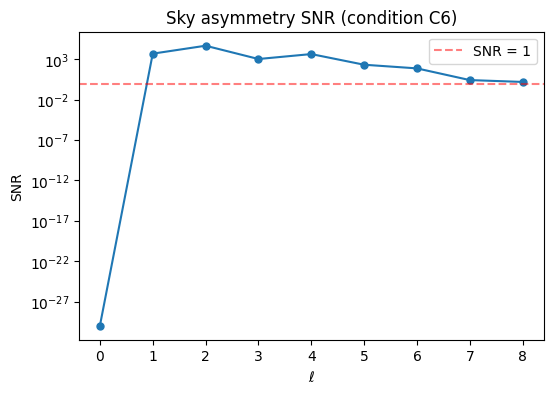

  l=0: SNR = 0.0  BELOW THRESHOLD
  l=1: SNR = 5036.4  OK
  l=2: SNR = 48421.5  OK
  l=3: SNR = 1092.7  OK
  l=4: SNR = 4473.4  OK
  l=5: SNR = 214.0  OK
  l=6: SNR = 75.5  OK
  l=7: SNR = 2.7  OK
  l=8: SNR = 1.6  OK


In [9]:
snr = sky_asymmetry_snr(sky_alm, beam_alm, NOISE_VAR, LMAX_WORK)

fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(ell, np.maximum(np.array(snr), 1e-30), "o-", ms=5)
ax.axhline(1.0, color="r", ls="--", alpha=0.5, label="SNR = 1")
ax.set_xlabel(r"$\ell$")
ax.set_ylabel("SNR")
ax.set_title("Sky asymmetry SNR (condition C6)")
ax.legend()
plt.show()

for l in range(L_WORK):
    status = "OK" if float(snr[l]) > 1 else "BELOW THRESHOLD"
    print(f"  l={l}: SNR = {float(snr[l]):.1f}  {status}")

## Fisher Information Matrix

The FIM gives the joint Cramér–Rao bound on all beam and sky parameters — the tightest possible precision for any unbiased estimator. It captures the information content of the rotation grid at a fiducial (beam, sky) point, including cross-correlations between beam and sky parameters.

The forward model uses the Wigner $D$-matrix measurement equation, with the LST rotation factored as a pure phase (valid in equatorial coordinates):

$$T_\text{ant}(R_i, t_j) = \text{Re}\!\left[\sum_{\ell,m,m'} \overline{b_{\ell m'}}\; \overline{D^\ell_{mm'}(R_{\text{fixed},i})}\; e^{imt_j}\; a_{\ell m}\right]$$

The FIM is $\mathcal{F} = J^T J / \sigma^2$ where $J = \partial \mathbf{y} / \partial \boldsymbol{\theta}$ is the Jacobian of the flattened observation vector with respect to the packed real (beam, sky) parameters. We use only the independent real parameters (respecting the reality condition $a_{\ell,-m} = (-1)^m \bar{a}_{\ell,m}$), giving $L^2$ parameters per field and $2L^2$ total.

**Expected structure:**
- The FIM should have $L = \ell_\text{max}+1$ near-zero eigenvalues, corresponding to the one beam–sky scale ambiguity $\alpha_\ell$ per multipole order (memo Sec. 3). These are resolved by the ground term linear system (Step 2 of the theorem).
- The condition number reveals how well-conditioned the joint estimation problem is.
- Per-$\ell$ CRB bounds show which angular scales are best constrained by the rotation diversity.

In [10]:
# Use a random subset of rotations for the FIM (full grid is expensive)
rng = np.random.default_rng(42)
if N_rot_total > N_ROT_FIM:
    rot_idx = rng.choice(N_rot_total, N_ROT_FIM, replace=False)
    rotation_matrices_fim = rotation_matrices_all[rot_idx]
else:
    rotation_matrices_fim = rotation_matrices_all

N_rot_fim = rotation_matrices_fim.shape[0]
N_obs = N_rot_fim * N_LST
N_params = 2 * L_WORK**2
print(f"FIM setup: {N_rot_fim} rotations x {N_LST} LSTs = {N_obs} observations")
print(f"Parameters: {N_params} ({L_WORK**2} beam + {L_WORK**2} sky)")

# Precompute Wigner D-matrices for the FIM rotation subset
print("Computing Wigner D-matrices...")
D_all = _rotmats_to_D(rotation_matrices_fim, LMAX_WORK)
print(f"D-matrices shape: {D_all.shape}")

# Phase factors: phase[j, m_idx] = exp(i * m * lst_j)
m_vals = jnp.arange(-(L_WORK - 1), L_WORK)
phase = jnp.exp(1j * jnp.outer(jnp.array(LSTS_RAD), m_vals))
D_conj = jnp.conj(D_all)


def simulator_fn(beam_alm, sky_alm):
    """Wigner D-matrix forward model: (beam_alm, sky_alm) -> antenna temps."""
    # Contract D* with b*: X[i,l,m] = sum_{m'} D*[i,l,m,m'] * b*[l,m']
    X = jnp.einsum("ilmp,lp->ilm", D_conj, jnp.conj(beam_alm))
    # Contract with sky and LST phase: y[i,j] = sum_{l,m} X[i,l,m] * phase[j,m] * a[l,m]
    Y = jnp.einsum("ilm,jm,lm->ij", X, phase, sky_alm)
    return Y


# Verify forward model produces real output
y_test = simulator_fn(beam_alm, sky_alm)
print(f"Forward model output: shape={y_test.shape}, max|imag|={float(jnp.max(jnp.abs(y_test.imag))):.2e}")

FIM setup: 100 rotations x 24 LSTs = 2400 observations
Parameters: 162 (81 beam + 81 sky)
Computing Wigner D-matrices...
D-matrices shape: (100, 9, 17, 17)
Forward model output: shape=(100, 24), max|imag|=4.83e-13


In [11]:
%%time
# Compute the Fisher information matrix
fim, J = compute_fim(simulator_fn, beam_alm, sky_alm, NOISE_VAR, LMAX_WORK)
print(f"FIM shape: {fim.shape}")
print(f"Jacobian shape: {J.shape}")
print(f"FIM symmetry check: max|F - F^T| = {float(jnp.max(jnp.abs(fim - fim.T))):.2e}")

FIM shape: (162, 162)
Jacobian shape: (2400, 162)
FIM symmetry check: max|F - F^T| = 0.00e+00
CPU times: user 9.86 s, sys: 1.55 s, total: 11.4 s
Wall time: 9.04 s


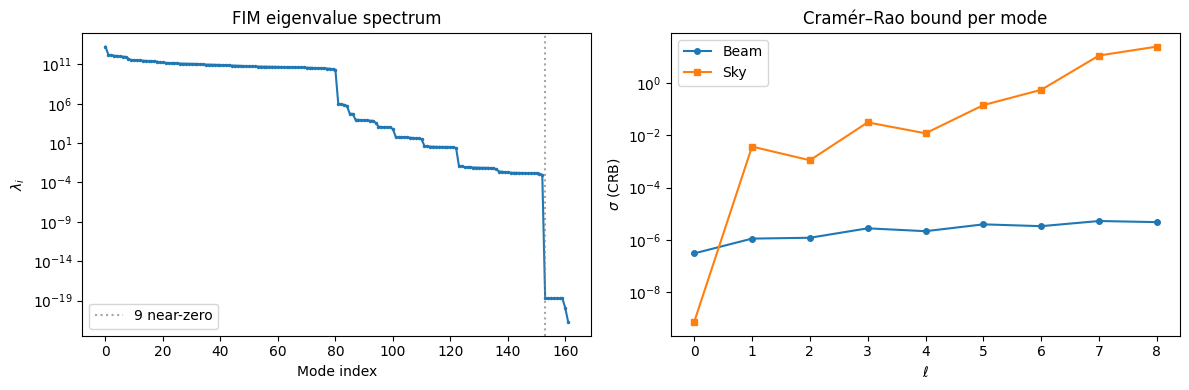

Condition number (J): 1.41e+08
Near-zero singular values: 9
Expected degeneracies: 9 (one beam-sky scale ambiguity per ell)


In [12]:
# Analyze FIM eigenspectrum via SVD of J (avoids squaring condition number)
J_np = np.array(J)
_U, s, Vt = np.linalg.svd(J_np, full_matrices=False)
eigvals = s**2 / NOISE_VAR  # FIM eigenvalues
tol = max(J_np.shape) * np.finfo(float).eps * s[0]
n_beam = L_WORK**2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Panel 1: eigenvalue spectrum
ax1.semilogy(np.arange(len(eigvals)), np.maximum(eigvals, 1e-30), ".-", ms=3)
n_zero = int(np.sum(s < tol))
if n_zero > 0:
    ax1.axvline(
        len(eigvals) - n_zero, color="gray", ls=":", alpha=0.7,
        label=f"{n_zero} near-zero",
    )
    ax1.legend()
ax1.set_xlabel("Mode index")
ax1.set_ylabel(r"$\lambda_i$")
ax1.set_title("FIM eigenvalue spectrum")

# Panel 2: CRB per ell (SVD-based pseudo-inverse)
mask = s > tol
inv_s2 = np.zeros_like(s)
inv_s2[mask] = 1.0 / s[mask] ** 2
crb = NOISE_VAR * np.sum(Vt**2 * inv_s2[:, None], axis=0)
beam_sigma = np.zeros(L_WORK)
sky_sigma = np.zeros(L_WORK)
for l in range(L_WORK):
    start = l * l
    width = 2 * l + 1
    beam_sigma[l] = np.sqrt(np.mean(np.maximum(crb[start : start + width], 0)))
    sky_sigma[l] = np.sqrt(
        np.mean(np.maximum(crb[n_beam + start : n_beam + start + width], 0))
    )

ax2.semilogy(ell, np.maximum(beam_sigma, 1e-30), "o-", label="Beam", ms=4)
ax2.semilogy(ell, np.maximum(sky_sigma, 1e-30), "s-", label="Sky", ms=4)
ax2.set_xlabel(r"$\ell$")
ax2.set_ylabel(r"$\sigma$ (CRB)")
ax2.set_title("Cram\u00e9r\u2013Rao bound per mode")
ax2.legend()

fig.tight_layout()
plt.show()

print(f"Condition number (J): {s[0] / s[mask][-1]:.2e}")
print(f"Near-zero singular values: {n_zero}")
print(f"Expected degeneracies: {L_WORK} (one beam-sky scale ambiguity per ell)")

## Five-Panel Summary

Combined view of all Milestone 1 diagnostics. The five panels correspond to the five quantities that characterize the systematic floor before any inference is attempted:

1. **FIM eigenvalue spectrum** — information content and degeneracy structure
2. **Cramér–Rao bound per $\ell$** — achievable precision for beam and sky at each angular scale
3. **Coverage kernel leakage** — error term (i), the deterministic bias from finite SO(3) sampling
4. **LST sampling error** — error term (ii), the discrete sidereal quadrature bias
5. **Sky asymmetry SNR** — condition C6, whether beam shape is recoverable per $\ell$

Panels 3–5 define the **systematic floor**: these biases exist regardless of integration time and directly inform which beam modes the Milestone 2 prior sweep should target.

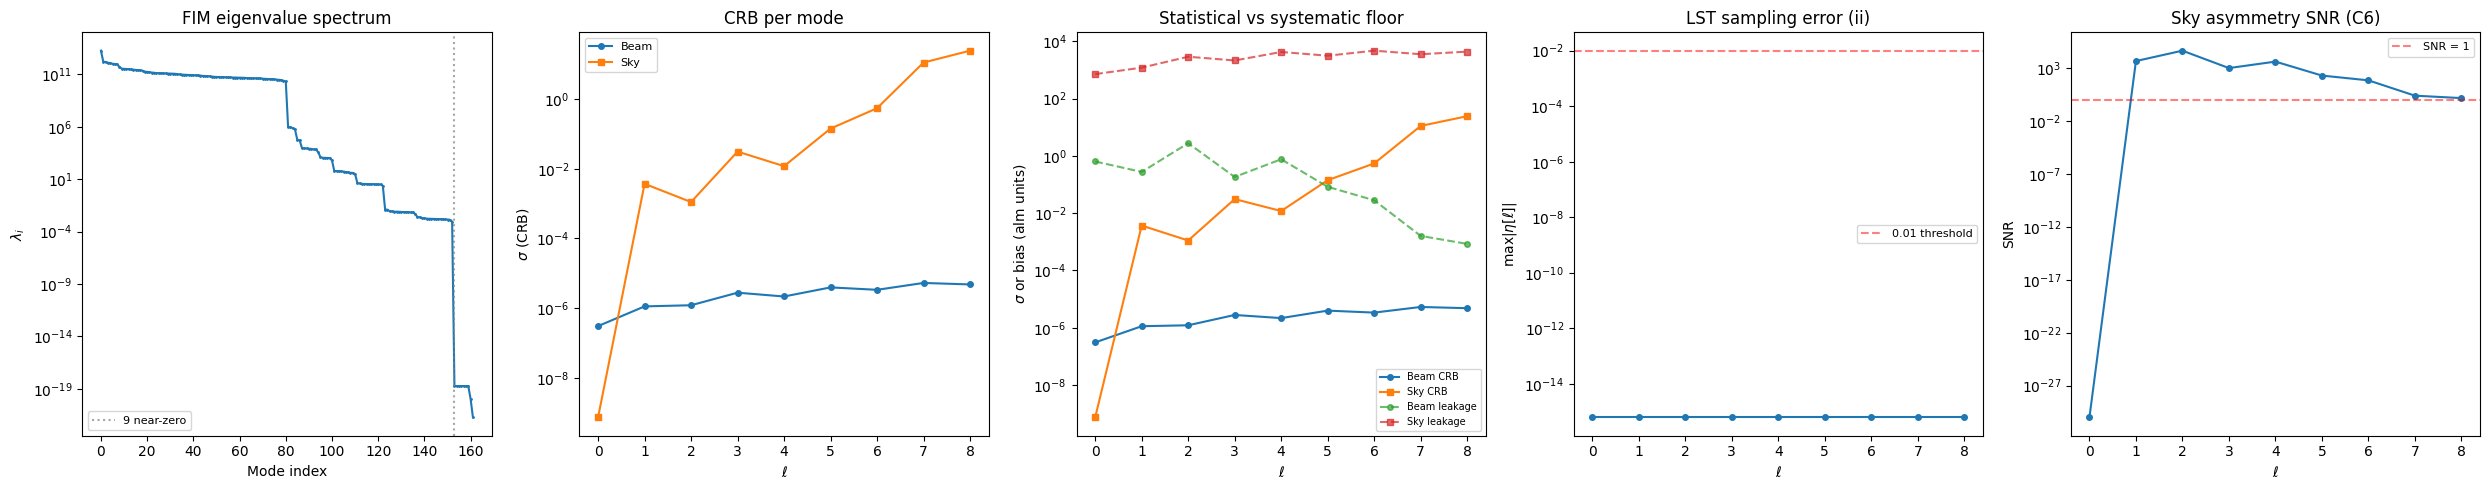

In [13]:
fig = plot_milestone1_summary(
    J, NOISE_VAR, beam_alm, sky_alm,
    diagonal, offdiag_power, eta, snr, LMAX_WORK,
)
plt.show()

## Interpretation and Implications for Milestone 2

### Which error term dominates?

The three error terms set different floors at different $\ell$:
- **Error (i), cross-$\ell$ leakage**: depends on the rotation grid density. With 1296 mechanical orientations, leakage is small at low $\ell$ but grows for higher multipoles where the grid undersamples SO(3). This bias is correctable at the cost of noise amplification (memo Sec. 4.1).
- **Error (ii), LST sampling**: negligible at our working $\ell_\text{max} = 8$ since we're well below the Nyquist limit ($|m| < 12$). Would become relevant if we pushed to higher resolution.
- **Error (iii), noise**: the CRB from the FIM sets the noise floor. The gap between CRB and the systematic biases (i)+(ii) determines how much integration time helps.

### Beam–sky degeneracy

The near-zero FIM eigenvalues reflect the per-$\ell$ beam–sky scale ambiguity ($\alpha_\ell$) inherent to the bilinear measurement equation. These $L$ degeneracies are **expected** and will be resolved by the ground term linear system (Step 2 of the constructive estimator) — they are not a failure of the rotation grid.

### Implications for the prior sweep

The CRB per $\ell$ directly informs the prior sweep (memo Sec. 5): at each $\ell$, the CRB tells us the noise floor that the posterior width $\sigma_\ell^\text{post}$ will approach in the data-dominated regime ($\sigma_\ell^\text{prior} \to \infty$). The crossover between prior-dominated and data-dominated regimes determines which beam modes benefit from rotation diversity beyond the HFSS simulation.

### Condition C6 check

Sky asymmetry SNR values above 1 at all working $\ell$ confirm that beam shape recovery is feasible from the LST residual. Any $\ell$-modes falling below SNR $= 1$ should be excluded via `skip_l` in the Milestone 2 constructive estimator and given flat priors in the Gibbs sampler.